# SCRC with Strict FNR Control — LR-DRE vs GNN-DRE

**Clinical mandate**: Never miss a positive (strict FNR ≤ 0.10 per pathology).

**Architecture**: Two-stage SCRC (Selective Conformal Risk Control)
- Stage 1: Global entropy-based deferral (β = 0.15)
- Stage 2: Per-pathology strict FNR calibration with DRE-weighted quantile

| Method | DRE space | PCA | Clip | Expected ESS |
|--------|-----------|-----|------|--------------|
| LR-DRE | 1024-dim raw features | PCA(4) | 20.0 | ~6% |
| GNN-DRE | 7-dim GNN probability space | None | None | ~31% |

**Research question**: Does GNN-DRE's higher ESS translate into lower FPR
while both methods maintain FNR ≤ α = 0.10?

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

ROOT = Path('../..').resolve()
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from wcp_l2d.dre import AdaptiveDRE
from wcp_l2d.features import ExtractedFeatures
from wcp_l2d.gnn import build_adjacency_matrix, train_gnn
from wcp_l2d.pathologies import COMMON_PATHOLOGIES
from wcp_l2d.scrc import multilabel_entropy, select_for_deferral

# --- Constants ---
SEED  = 42
BETA  = 0.15   # Stage 1 deferral budget
ALPHA = 0.10   # Stage 2 FNR target
K     = len(COMMON_PATHOLOGIES)
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'

np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update({
    'figure.dpi': 100,
    'figure.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print(f'Device:      {DEVICE}')
print(f'Pathologies: {COMMON_PATHOLOGIES}')
print(f'BETA={BETA}  ALPHA={ALPHA}  SEED={SEED}')

Device:      mps
Pathologies: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Pneumonia', 'Pneumothorax']
BETA=0.15  ALPHA=0.1  SEED=42


## 1. Load Features

In [2]:
FEAT_DIR = ROOT / 'data' / 'features'
chex = ExtractedFeatures.load(FEAT_DIR / 'chexpert_densenet121-res224-chex_features.npz')
nih  = ExtractedFeatures.load(FEAT_DIR / 'nih_densenet121-res224-chex_features.npz')

print(f'CheXpert: {chex.features.shape}  labels: {chex.labels.shape}')
print(f'NIH:      {nih.features.shape}   labels: {nih.labels.shape}')

CheXpert: (64534, 1024)  labels: (64534, 7)
NIH:      (30805, 1024)   labels: (30805, 7)


## 2. Data Splits (identical to gnn_lsc_wcp.ipynb, SEED=42)

- CheXpert (64,534): 60% train / 20% cal / 20% ignored
- NIH (30,805): 50% DRE pool / 50% labelled test
- StandardScaler fit on train, applied to cal/pool/test

In [3]:
rng = np.random.RandomState(SEED)

# --- CheXpert: 60% train / 20% cal / 20% ignored ---
N_chex = len(chex.features)
idx    = rng.permutation(N_chex)
n_tr   = int(0.60 * N_chex)
n_cal  = int(0.20 * N_chex)

X_train_raw = chex.features[idx[:n_tr]]
Y_train     = chex.labels[idx[:n_tr]]
X_cal_raw   = chex.features[idx[n_tr:n_tr + n_cal]]
Y_cal       = chex.labels[idx[n_tr:n_tr + n_cal]]

# --- NIH: 50% DRE pool / 50% labelled test ---
N_nih    = len(nih.features)
nih_perm = rng.permutation(N_nih)
n_pool   = N_nih // 2

X_pool_raw = nih.features[nih_perm[:n_pool]]
X_nih_raw  = nih.features[nih_perm[n_pool:]]
Y_nih_test = nih.labels[nih_perm[n_pool:]]

# StandardScaler fitted on train set
scaler  = StandardScaler().fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_cal   = scaler.transform(X_cal_raw)
X_pool  = scaler.transform(X_pool_raw)
X_nih   = scaler.transform(X_nih_raw)

print(f'CheXpert  train={len(X_train):,}  cal={len(X_cal):,}')
print(f'NIH       pool={len(X_pool):,}   test={len(X_nih):,}')

CheXpert  train=38,720  cal=12,906
NIH       pool=15,402   test=15,403


## 3. Binary LR Classifiers (for GNN residual init)

In [4]:
lrs = []
for k, path in enumerate(COMMON_PATHOLOGIES):
    valid = ~np.isnan(Y_train[:, k])
    if valid.sum() < 10 or len(np.unique(Y_train[valid, k])) < 2:
        lrs.append(None)
        continue
    lr = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=SEED)
    lr.fit(X_train[valid], Y_train[valid, k].astype(int))
    lrs.append(lr)


def get_logits_lr(lrs_, X_s):
    """[N, K] decision function from 7 binary LRs."""
    out = np.zeros((len(X_s), K), dtype=np.float32)
    for k, lr in enumerate(lrs_):
        if lr is not None:
            out[:, k] = lr.decision_function(X_s)
    return out


init_tr   = get_logits_lr(lrs, X_train)
init_cal  = get_logits_lr(lrs, X_cal)
init_pool = get_logits_lr(lrs, X_pool)
init_nih  = get_logits_lr(lrs, X_nih)
print('LR classifiers trained.')

LR classifiers trained.


## 4. Label Co-occurrence Adjacency Matrix

In [5]:
A = build_adjacency_matrix(Y_train, tau=0.10)
assert torch.allclose(A.sum(dim=1), torch.ones(K), atol=1e-5), 'Row sums must equal 1'
print(f'Adjacency matrix: {A.shape}  non-zero off-diagonal: {int((A > 0).sum()) - K}/{K*(K-1)}')

Adjacency matrix: torch.Size([7, 7])  non-zero off-diagonal: 33/42


## 5. Train LabelGCN (50 epochs)

In [6]:
print(f'Training LabelGCN on {DEVICE} (50 epochs) ...')

gnn, history = train_gnn(
    features_train=X_train,
    labels_train=Y_train,
    features_val=X_cal,
    labels_val=Y_cal,
    adjacency=A,
    init_logits_train=init_tr,
    init_logits_val=init_cal,
    epochs=50,
    save_best=True,
    batch_size=512,
    lr=1e-3,
    weight_decay=1e-4,
    device=DEVICE,
    verbose=False,
)

best_ep = history['best_epoch'][0]
print(f'Best val AUC: {max(history["val_auc"]):.4f}  at epoch {best_ep}/50')

Training LabelGCN on mps (50 epochs) ...


Best val AUC: 0.8325  at epoch 20/50


## 6. GNN Probability Extraction

In [7]:
def gnn_probs_fn(model, X_s, init_np=None):
    """Forward pass → sigmoid probabilities [N, K]."""
    model.eval()
    with torch.no_grad():
        Xt = torch.tensor(X_s, dtype=torch.float32)
        it = torch.tensor(init_np, dtype=torch.float32) if init_np is not None else None
        logits = model(Xt, it).numpy()
    return 1.0 / (1.0 + np.exp(-logits))


p_cal  = gnn_probs_fn(gnn, X_cal,  init_cal)
p_pool = gnn_probs_fn(gnn, X_pool, init_pool)
p_nih  = gnn_probs_fn(gnn, X_nih,  init_nih)

print(f'GNN probs: p_cal={p_cal.shape}  p_pool={p_pool.shape}  p_nih={p_nih.shape}')

# Per-pathology AUC on NIH test
auc_rows = []
for k, path in enumerate(COMMON_PATHOLOGIES):
    valid = ~np.isnan(Y_nih_test[:, k])
    if valid.sum() < 2 or len(np.unique(Y_nih_test[valid, k])) < 2:
        auc_rows.append({'Pathology': path, 'GNN AUC': float('nan')})
        continue
    auc = roc_auc_score(Y_nih_test[valid, k], p_nih[valid, k])
    auc_rows.append({'Pathology': path, 'GNN AUC': round(auc, 4)})

auc_df = pd.DataFrame(auc_rows).set_index('Pathology')
gnn_aucs = auc_df['GNN AUC'].values
print(f'\nNIH GNN AUC (mean={np.nanmean(gnn_aucs):.4f}):')
print(auc_df.T.to_string())

GNN probs: p_cal=(12906, 7)  p_pool=(15402, 7)  p_nih=(15403, 7)

NIH GNN AUC (mean=0.7410):
Pathology  Atelectasis  Cardiomegaly  Consolidation   Edema  Effusion  Pneumonia  Pneumothorax
GNN AUC         0.7069         0.768         0.7461  0.8284    0.8311      0.679        0.6278


## 7. Classifier AUC Comparison — LR vs GNN (NIH Test Set)

Both classifiers are trained on CheXpert and evaluated on NIH.
This measures discriminative quality before any SCRC calibration.

NIH Test AUC Comparison: LR vs GNN
               LR AUC  GNN AUC  ΔAUC (GNN−LR)
Pathology                                    
Atelectasis    0.6868   0.7069         0.0201
Cardiomegaly   0.7393   0.7680         0.0287
Consolidation  0.7252   0.7461         0.0209
Edema          0.8163   0.8284         0.0121
Effusion       0.8031   0.8311         0.0280
Pneumonia      0.6286   0.6790         0.0504
Pneumothorax   0.5674   0.6278         0.0604

Mean LR  AUC: 0.7095
Mean GNN AUC: 0.7410
Mean ΔAUC:    +0.0315
GNN > LR in 7/7 pathologies


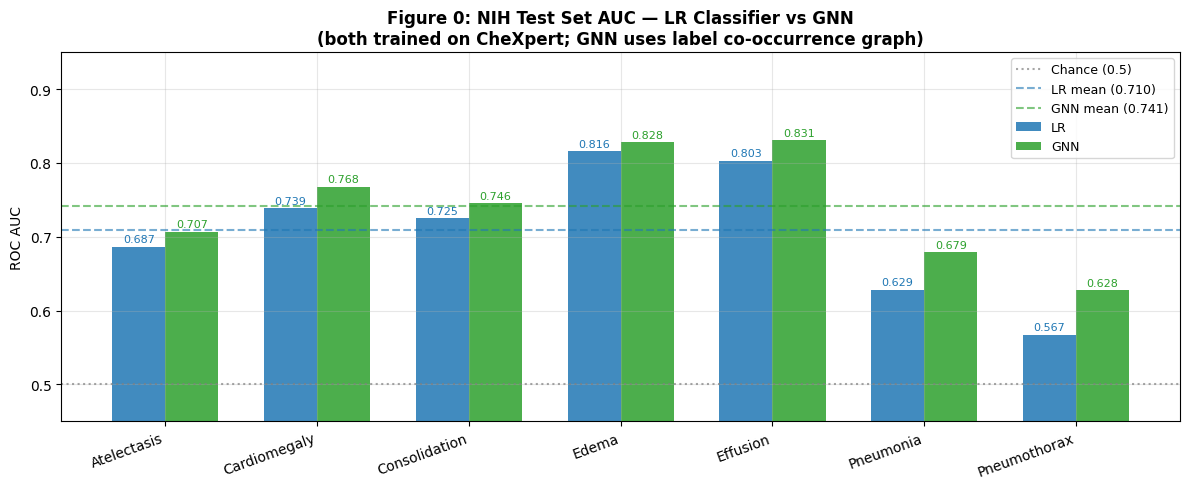

In [8]:
# --- Per-pathology LR AUC on NIH test ---
lr_auc_rows = []
for k, path in enumerate(COMMON_PATHOLOGIES):
    valid = ~np.isnan(Y_nih_test[:, k])
    if valid.sum() < 2 or len(np.unique(Y_nih_test[valid, k])) < 2 or lrs[k] is None:
        lr_auc_rows.append({'Pathology': path, 'LR AUC': float('nan')})
        continue
    proba = lrs[k].predict_proba(X_nih[valid])[:, 1]
    auc = roc_auc_score(Y_nih_test[valid, k], proba)
    lr_auc_rows.append({'Pathology': path, 'LR AUC': round(auc, 4)})

lr_auc_df = pd.DataFrame(lr_auc_rows).set_index('Pathology')
lr_aucs = lr_auc_df['LR AUC'].values

# --- Comparison table ---
auc_comp = pd.DataFrame({
    'LR AUC':          np.round(lr_aucs, 4),
    'GNN AUC':         np.round(gnn_aucs, 4),
    'ΔAUC (GNN−LR)':   np.round(gnn_aucs - lr_aucs, 4),
}, index=COMMON_PATHOLOGIES)
auc_comp.index.name = 'Pathology'

print('NIH Test AUC Comparison: LR vs GNN')
print('=' * 50)
print(auc_comp.to_string())
print(f'\nMean LR  AUC: {np.nanmean(lr_aucs):.4f}')
print(f'Mean GNN AUC: {np.nanmean(gnn_aucs):.4f}')
print(f'Mean ΔAUC:    {np.nanmean(gnn_aucs - lr_aucs):+.4f}')
print(f'GNN > LR in {int((gnn_aucs > lr_aucs).sum())}/{K} pathologies')

# Store for later use
lr_aucs_arr  = lr_aucs
gnn_aucs_arr = gnn_aucs

# --- Bar chart ---
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(K)
width = 0.35

bars_lr  = ax.bar(x - width/2, lr_aucs,  width, label='LR',  color='#1f77b4', alpha=0.85)
bars_gnn = ax.bar(x + width/2, gnn_aucs, width, label='GNN', color='#2ca02c', alpha=0.85)

for bar, val in zip(bars_lr, lr_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, color='#1f77b4')
for bar, val in zip(bars_gnn, gnn_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, color='#2ca02c')

ax.axhline(0.5, color='gray', linestyle=':', lw=1.5, alpha=0.7, label='Chance (0.5)')
ax.axhline(np.nanmean(lr_aucs),  color='#1f77b4', linestyle='--', lw=1.5, alpha=0.6,
           label=f'LR mean ({np.nanmean(lr_aucs):.3f})')
ax.axhline(np.nanmean(gnn_aucs), color='#2ca02c', linestyle='--', lw=1.5, alpha=0.6,
           label=f'GNN mean ({np.nanmean(gnn_aucs):.3f})')

ax.set_xticks(x)
ax.set_xticklabels(COMMON_PATHOLOGIES, rotation=20, ha='right')
ax.set_ylabel('ROC AUC')
ax.set_ylim(0.45, 0.95)
ax.set_title('Figure 0: NIH Test Set AUC — LR Classifier vs GNN\n'
             '(both trained on CheXpert; GNN uses label co-occurrence graph)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8. LR-DRE

Source = CheXpert calibration set (**1024-dim raw features**)  
Target = NIH unlabelled pool (1024-dim raw features)  
PCA(n_components=4), weight_clip=20.0

In [9]:
dre_lr = AdaptiveDRE(n_components=4, weight_clip=20.0, random_state=SEED)
dre_lr.fit(source_features=X_cal, target_features=X_pool)

w_cal_lr  = dre_lr.compute_weights(X_cal)
w_nih_lr  = dre_lr.compute_weights(X_nih)
diag_lr   = dre_lr.diagnostics(X_cal)

print('=== LR-DRE Diagnostics (CheXpert cal set) ===')
print(f'  Domain AUC : {diag_lr.domain_auc:.4f}')
print(f'  ESS        : {diag_lr.ess:.1f}  ({diag_lr.ess_fraction*100:.1f}%)')
print(f'  Weight mean: {diag_lr.weight_mean:.3f}  median: {diag_lr.weight_median:.3f}  max: {diag_lr.weight_max:.3f}')

=== LR-DRE Diagnostics (CheXpert cal set) ===
  Domain AUC : 0.9656
  ESS        : 772.9  (6.0%)
  Weight mean: 0.582  median: 0.036  max: 20.000


## 9. LR-DRE (no clip)

Same PCA(4) pipeline as LR-DRE but **weight_clip=None** — no upper bound on importance weights.  
Isolates the effect of clipping on ESS, calibration thresholds, and test performance.

In [10]:
dre_lr_nc = AdaptiveDRE(n_components=4, weight_clip=None, random_state=SEED)
dre_lr_nc.fit(source_features=X_cal, target_features=X_pool)

w_cal_lr_nc = dre_lr_nc.compute_weights(X_cal)
w_nih_lr_nc = dre_lr_nc.compute_weights(X_nih)
diag_lr_nc  = dre_lr_nc.diagnostics(X_cal)

print('=== LR-DRE (no clip) Diagnostics ===')
print(f'  Domain AUC : {diag_lr_nc.domain_auc:.4f}')
print(f'  ESS        : {diag_lr_nc.ess:.1f}  ({diag_lr_nc.ess_fraction*100:.2f}%)')
print(f'  Weight mean: {diag_lr_nc.weight_mean:.3f}  median: {diag_lr_nc.weight_median:.3f}  '
      f'max: {diag_lr_nc.weight_max:.1f}')
print(f'  (vs LR-DRE clipped: ESS={diag_lr.ess_fraction*100:.2f}%  '
      f'max={diag_lr.weight_max:.1f})')

=== LR-DRE (no clip) Diagnostics ===
  Domain AUC : 0.9656
  ESS        : 33.1  (0.26%)
  Weight mean: 1.223  median: 0.036  max: 2510.5
  (vs LR-DRE clipped: ESS=5.99%  max=20.0)


## 10. GNN-DRE

Source = CheXpert calibration set (**7-dim GNN probability space**)  
Target = NIH unlabelled pool (7-dim GNN probability space)  
n_components=None (no PCA), weight_clip=None (no clipping)

In [11]:
dre_gnn = AdaptiveDRE(n_components=None, weight_clip=None, random_state=SEED)
dre_gnn.fit(source_features=p_cal, target_features=p_pool)

w_cal_gnn = dre_gnn.compute_weights(p_cal)
w_nih_gnn = dre_gnn.compute_weights(p_nih)
diag_gnn  = dre_gnn.diagnostics(p_cal)

print('=== GNN-DRE Diagnostics (CheXpert cal set) ===')
print(f'  Domain AUC : {diag_gnn.domain_auc:.4f}')
print(f'  ESS        : {diag_gnn.ess:.1f}  ({diag_gnn.ess_fraction*100:.1f}%)')
print(f'  Weight mean: {diag_gnn.weight_mean:.3f}  median: {diag_gnn.weight_median:.3f}  max: {diag_gnn.weight_max:.3f}')

=== GNN-DRE Diagnostics (CheXpert cal set) ===
  Domain AUC : 0.8439
  ESS        : 3983.9  (30.9%)
  Weight mean: 0.939  median: 0.345  max: 50.540


## 11. GNN-DRE (clip=20)

Same 7-dim probability space as GNN-DRE but **weight_clip=20.0** (matching LR-DRE clip). This tests whether clipping removes the heavy tail of GNN weights while preserving the ESS advantage from lower domain separability.


In [12]:
dre_gnn_clip = AdaptiveDRE(n_components=None, weight_clip=20.0, random_state=SEED)
dre_gnn_clip.fit(source_features=p_cal, target_features=p_pool)
w_cal_gnn_clip = dre_gnn_clip.compute_weights(p_cal)
w_nih_gnn_clip = dre_gnn_clip.compute_weights(p_nih)
diag_gnn_clip  = dre_gnn_clip.diagnostics(p_cal)
print(f'GNN-DRE (clip=20): domain_AUC={diag_gnn_clip.domain_auc:.4f}, '
      f'ESS%={diag_gnn_clip.ess_fraction * 100:.1f}%, '
      f'w_max={w_cal_gnn_clip.max():.1f}')


GNN-DRE (clip=20): domain_AUC=0.8439, ESS%=32.6%, w_max=20.0


## 12. Table 1: DRE Weight Quality

In [13]:
dre_table = pd.DataFrame([
    {'Method': 'LR-DRE (clip=20)',      'Domain AUC': round(diag_lr.domain_auc, 4),
     'ESS%': round(diag_lr.ess_fraction * 100, 1),
     'W_mean': round(float(w_cal_lr.mean()), 2),   'W_max': round(float(w_cal_lr.max()), 1)},
    {'Method': 'LR-DRE (no clip)',      'Domain AUC': round(diag_lr_nc.domain_auc, 4),
     'ESS%': round(diag_lr_nc.ess_fraction * 100, 1),
     'W_mean': round(float(w_cal_lr_nc.mean()), 2), 'W_max': round(float(w_cal_lr_nc.max()), 1)},
    {'Method': 'GNN-DRE (no clip)',     'Domain AUC': round(diag_gnn.domain_auc, 4),
     'ESS%': round(diag_gnn.ess_fraction * 100, 1),
     'W_mean': round(float(w_cal_gnn.mean()), 2),  'W_max': round(float(w_cal_gnn.max()), 1)},
    {'Method': 'GNN-DRE (clip=20)',     'Domain AUC': round(diag_gnn_clip.domain_auc, 4),
     'ESS%': round(diag_gnn_clip.ess_fraction * 100, 1),
     'W_mean': round(float(w_cal_gnn_clip.mean()), 2), 'W_max': round(float(w_cal_gnn_clip.max()), 1)},
])
print(dre_table.to_string(index=False))


           Method  Domain AUC  ESS%  W_mean  W_max
 LR-DRE (clip=20)      0.9656   6.0    0.58   20.0
 LR-DRE (no clip)      0.9656   0.3    1.22 2510.5
GNN-DRE (no clip)      0.8439  30.9    0.94   50.5
GNN-DRE (clip=20)      0.8439  32.6    0.94   20.0


## 13. Stage 1 — Global Uncertainty Deferral (β = 0.15)

Compute multi-label entropy from GNN probabilities, defer top-β fraction.  
Stage 1 is **identical** for both LR-DRE and GNN-DRE (entropy from GNN probs either way).

In [14]:
# Calibration set: Stage 1 deferral
entropy_cal = multilabel_entropy(p_cal)          # [N_cal]
defer_mask_cal = select_for_deferral(entropy_cal, BETA, seed=SEED)

# NIH test set: Stage 1 deferral
entropy_nih = multilabel_entropy(p_nih)          # [N_nih]
defer_mask_nih = select_for_deferral(entropy_nih, BETA, seed=SEED)

print(f'Stage 1 (β={BETA})')
print(f'  Cal:  {defer_mask_cal.sum()} / {len(defer_mask_cal)} deferred  '
      f'({defer_mask_cal.mean()*100:.1f}%)  kept: {(~defer_mask_cal).sum()}')
print(f'  Test: {defer_mask_nih.sum()} / {len(defer_mask_nih)} deferred  '
      f'({defer_mask_nih.mean()*100:.1f}%)  kept: {(~defer_mask_nih).sum()}')

# Verify deferral rate ≤ beta
assert defer_mask_cal.mean() <= BETA + 1e-9, 'Cal deferral rate exceeds beta!'
assert defer_mask_nih.mean() <= BETA + 1e-9, 'Test deferral rate exceeds beta!'

Stage 1 (β=0.15)
  Cal:  1935 / 12906 deferred  (15.0%)  kept: 10971
  Test: 2310 / 15403 deferred  (15.0%)  kept: 13093


## 14. Stage 2 — Per-Pathology Strict FNR Calibration (α = 0.10)

For each pathology k, on the **non-deferred calibration subset**:

$$\text{FNR}_k(\lambda) = \frac{\sum_{i: y_{ik}=1, \neg\text{defer}} w_i \cdot \mathbf{1}[p_{ik} < \lambda]}{\sum_{i: y_{ik}=1, \neg\text{defer}} w_i}$$

$$\lambda_k^* = \max\{\lambda : \text{FNR}_k(\lambda) \leq \alpha\}$$

**Denominator = positives only** (strict formula, different from per-sample average).

In [15]:
def calibrate_strict_fnr(
    gnn_probs_cal, labels_cal, dre_weights_cal, defer_mask_cal,
    alpha=0.10, n_grid=1001
):
    """Weighted FNR calibration (denominator = positives only)."""
    kept   = ~defer_mask_cal
    p_kept = gnn_probs_cal[kept]
    y_kept = labels_cal[kept]
    w_kept = dre_weights_cal[kept]
    K = p_kept.shape[1]
    candidates   = np.linspace(0, 1, n_grid)
    lambda_stars = np.zeros(K)
    cal_fnrs     = np.zeros(K)
    n_positives  = np.zeros(K, dtype=int)

    for k in range(K):
        valid_k = ~np.isnan(y_kept[:, k])
        pos_k   = valid_k & (y_kept[:, k] == 1)
        n_positives[k] = int(pos_k.sum())
        if pos_k.sum() < 2:
            lambda_stars[k] = 0.0
            continue
        p_k   = p_kept[pos_k, k]
        w_k   = w_kept[pos_k]
        missed   = p_k[np.newaxis, :] < candidates[:, np.newaxis]   # [G, N+]
        fnr_grid = (missed * w_k[np.newaxis, :]).sum(axis=1) / w_k.sum()
        valid_mask = fnr_grid <= alpha
        if valid_mask.any():
            best_idx = int(np.where(valid_mask)[0][-1])
            lambda_stars[k] = float(candidates[best_idx])
            cal_fnrs[k]     = float(fnr_grid[best_idx])
        else:
            lambda_stars[k] = 0.0
            cal_fnrs[k]     = float(fnr_grid[0])
    return lambda_stars, cal_fnrs, n_positives

# --- Run for all four methods ---
lambda_lr,       cal_fnr_lr,       n_pos_lr       = calibrate_strict_fnr(
    p_cal, Y_cal, w_cal_lr,       defer_mask_cal, alpha=ALPHA)
lambda_lr_nc,    cal_fnr_lr_nc,    n_pos_lr_nc    = calibrate_strict_fnr(
    p_cal, Y_cal, w_cal_lr_nc,    defer_mask_cal, alpha=ALPHA)
lambda_gnn,      cal_fnr_gnn,      n_pos_gnn      = calibrate_strict_fnr(
    p_cal, Y_cal, w_cal_gnn,      defer_mask_cal, alpha=ALPHA)
lambda_gnn_clip, cal_fnr_gnn_clip, n_pos_gnn_clip = calibrate_strict_fnr(
    p_cal, Y_cal, w_cal_gnn_clip, defer_mask_cal, alpha=ALPHA)

print(f"{'Pathology':15s} | {'LR(c) λ*':8s} {'FNR':5s} | {'LR(nc) λ*':9s} {'FNR':5s} | {'GNN(nc) λ*':10s} {'FNR':5s} | {'GNN(c) λ*':9s} {'FNR':5s}")
print('-' * 95)
for k, path in enumerate(COMMON_PATHOLOGIES):
    print(f"{path:15s} | {lambda_lr[k]:.3f}    {cal_fnr_lr[k]:.3f} | {lambda_lr_nc[k]:.3f}     {cal_fnr_lr_nc[k]:.3f} | {lambda_gnn[k]:.3f}      {cal_fnr_gnn[k]:.3f} | {lambda_gnn_clip[k]:.3f}     {cal_fnr_gnn_clip[k]:.3f}")
print('-' * 95)
print(f"{'Mean':15s} | {lambda_lr.mean():.3f}    {cal_fnr_lr.mean():.3f} | {lambda_lr_nc.mean():.3f}     {cal_fnr_lr_nc.mean():.3f} | {lambda_gnn.mean():.3f}      {cal_fnr_gnn.mean():.3f} | {lambda_gnn_clip.mean():.3f}     {cal_fnr_gnn_clip.mean():.3f}")

# Sanity check: all cal FNRs ≤ alpha
for name, fnrs in [('LR(clip)', cal_fnr_lr), ('LR(nc)', cal_fnr_lr_nc),
                   ('GNN(nc)', cal_fnr_gnn), ('GNN(clip)', cal_fnr_gnn_clip)]:
    ok = (fnrs <= ALPHA + 1e-9).all()
    print(f"\nCal FNR ≤ {ALPHA} check [{name}]: {'ALL PASS ✓' if ok else 'FAIL ✗ at ' + str(COMMON_PATHOLOGIES[int((fnrs > ALPHA+1e-9).argmax())])}")


Pathology       | LR(c) λ* FNR   | LR(nc) λ* FNR   | GNN(nc) λ* FNR   | GNN(c) λ* FNR  
-----------------------------------------------------------------------------------------------
Atelectasis     | 0.118    0.094 | 0.168     0.095 | 0.109      0.100 | 0.109     0.100
Cardiomegaly    | 0.061    0.087 | 0.169     0.098 | 0.045      0.097 | 0.045     0.097
Consolidation   | 0.024    0.090 | 0.031     0.099 | 0.030      0.099 | 0.030     0.099
Edema           | 0.096    0.100 | 0.092     0.041 | 0.050      0.098 | 0.050     0.098
Effusion        | 0.091    0.096 | 0.178     0.088 | 0.037      0.097 | 0.037     0.097
Pneumonia       | 0.017    0.088 | 0.017     0.088 | 0.023      0.100 | 0.023     0.100
Pneumothorax    | 0.047    0.097 | 0.053     0.059 | 0.047      0.096 | 0.047     0.096
-----------------------------------------------------------------------------------------------
Mean            | 0.065    0.093 | 0.101     0.081 | 0.049      0.098 | 0.049     0.098

Cal FNR ≤ 0.1 c

## 15. Test Evaluation

For non-deferred test samples:
- Predict positive on pathology k iff `gnn_prob_k ≥ λ_k*`
- Empirical FNR_k = (# missed true positives) / (# true positives)
- Empirical FPR_k = (# false alarms) / (# true negatives)

In [16]:
def evaluate_test_fnr_fpr(gnn_probs_test, labels_test, defer_mask_test, lambda_stars):
    """Empirical FNR and FPR per pathology on non-deferred test samples."""
    kept   = ~defer_mask_test
    p_kept = gnn_probs_test[kept]
    y_kept = labels_test[kept]
    K = p_kept.shape[1]
    fnrs, fprs = np.zeros(K), np.zeros(K)
    for k in range(K):
        valid = ~np.isnan(y_kept[:, k])
        yv    = y_kept[valid, k]
        pv    = p_kept[valid, k]
        pred  = (pv >= lambda_stars[k]).astype(float)
        pos   = yv == 1;  neg = yv == 0
        fnrs[k] = (pred[pos] == 0).mean() if pos.sum() > 0 else float('nan')
        fprs[k] = (pred[neg] == 1).mean() if neg.sum() > 0 else float('nan')
    return fnrs, fprs

fnr_lr,       fpr_lr       = evaluate_test_fnr_fpr(p_nih, Y_nih_test, defer_mask_nih, lambda_lr)
fnr_lr_nc,    fpr_lr_nc    = evaluate_test_fnr_fpr(p_nih, Y_nih_test, defer_mask_nih, lambda_lr_nc)
fnr_gnn,      fpr_gnn      = evaluate_test_fnr_fpr(p_nih, Y_nih_test, defer_mask_nih, lambda_gnn)
fnr_gnn_clip, fpr_gnn_clip = evaluate_test_fnr_fpr(p_nih, Y_nih_test, defer_mask_nih, lambda_gnn_clip)

print(f"Deferred (NIH test): {defer_mask_nih.mean()*100:.1f}%")
print(f"\n{'Pathology':15s} | {'LR(c)':14s} | {'LR(nc)':14s} | {'GNN(nc)':14s} | {'GNN(c)':14s}")
print(f"{'':15s} | {'FNR':6s} {'FPR':6s} | {'FNR':6s} {'FPR':6s} | {'FNR':6s} {'FPR':6s} | {'FNR':6s} {'FPR':6s}")
print('-' * 85)
for k, path in enumerate(COMMON_PATHOLOGIES):
    print(f"{path:15s} | {fnr_lr[k]:.3f}  {fpr_lr[k]:.3f} | {fnr_lr_nc[k]:.3f}  {fpr_lr_nc[k]:.3f} | {fnr_gnn[k]:.3f}  {fpr_gnn[k]:.3f} | {fnr_gnn_clip[k]:.3f}  {fpr_gnn_clip[k]:.3f}")
print('-' * 85)
print(f"{'Mean':15s} | {np.nanmean(fnr_lr):.3f}  {np.nanmean(fpr_lr):.3f} | {np.nanmean(fnr_lr_nc):.3f}  {np.nanmean(fpr_lr_nc):.3f} | {np.nanmean(fnr_gnn):.3f}  {np.nanmean(fpr_gnn):.3f} | {np.nanmean(fnr_gnn_clip):.3f}  {np.nanmean(fpr_gnn_clip):.3f}")


Deferred (NIH test): 15.0%

Pathology       | LR(c)          | LR(nc)         | GNN(nc)        | GNN(c)        
                | FNR    FPR    | FNR    FPR    | FNR    FPR    | FNR    FPR   
-------------------------------------------------------------------------------------
Atelectasis     | 0.191  0.564 | 0.320  0.411 | 0.167  0.596 | 0.167  0.596
Cardiomegaly    | 0.209  0.377 | 0.612  0.102 | 0.134  0.484 | 0.134  0.484
Consolidation   | 0.132  0.658 | 0.215  0.545 | 0.207  0.559 | 0.207  0.559
Edema           | 0.263  0.385 | 0.263  0.397 | 0.158  0.581 | 0.158  0.581
Effusion        | 0.242  0.342 | 0.500  0.116 | 0.061  0.731 | 0.061  0.731
Pneumonia       | 0.102  0.884 | 0.102  0.884 | 0.122  0.803 | 0.122  0.803
Pneumothorax    | 0.259  0.673 | 0.318  0.593 | 0.259  0.673 | 0.259  0.673
-------------------------------------------------------------------------------------
Mean            | 0.200  0.555 | 0.333  0.435 | 0.158  0.632 | 0.158  0.632


## 16. Table 3: Test-Set Clinical Performance

In [17]:
rows = []
for k, path in enumerate(COMMON_PATHOLOGIES):
    rows.append({
        'Pathology':    path,
        'GNN AUC':      round(auc_rows[k]['GNN AUC'], 3),
        'LR(c) FNR':   round(fnr_lr[k], 3),  'LR(c) FPR':  round(fpr_lr[k], 3),
        'LR(nc) FNR':  round(fnr_lr_nc[k], 3),'LR(nc) FPR': round(fpr_lr_nc[k], 3),
        'GNN(nc) FNR': round(fnr_gnn[k], 3), 'GNN(nc) FPR':round(fpr_gnn[k], 3),
        'GNN(c) FNR':  round(fnr_gnn_clip[k], 3),'GNN(c) FPR':round(fpr_gnn_clip[k], 3),
    })
rows.append({
    'Pathology':    'Mean',
    'GNN AUC':      round(np.nanmean([r['GNN AUC'] for r in rows]), 3),
    'LR(c) FNR':   round(np.nanmean(fnr_lr), 3),  'LR(c) FPR':  round(np.nanmean(fpr_lr), 3),
    'LR(nc) FNR':  round(np.nanmean(fnr_lr_nc), 3),'LR(nc) FPR': round(np.nanmean(fpr_lr_nc), 3),
    'GNN(nc) FNR': round(np.nanmean(fnr_gnn), 3), 'GNN(nc) FPR':round(np.nanmean(fpr_gnn), 3),
    'GNN(c) FNR':  round(np.nanmean(fnr_gnn_clip), 3),'GNN(c) FPR':round(np.nanmean(fpr_gnn_clip), 3),
})
df_results = pd.DataFrame(rows)
print(df_results.to_string(index=False))


    Pathology  GNN AUC  LR(c) FNR  LR(c) FPR  LR(nc) FNR  LR(nc) FPR  GNN(nc) FNR  GNN(nc) FPR  GNN(c) FNR  GNN(c) FPR
  Atelectasis    0.707      0.191      0.564       0.320       0.411        0.167        0.596       0.167       0.596
 Cardiomegaly    0.768      0.209      0.377       0.612       0.102        0.134        0.484       0.134       0.484
Consolidation    0.746      0.132      0.658       0.215       0.545        0.207        0.559       0.207       0.559
        Edema    0.828      0.263      0.385       0.263       0.397        0.158        0.581       0.158       0.581
     Effusion    0.831      0.242      0.342       0.500       0.116        0.061        0.731       0.061       0.731
    Pneumonia    0.679      0.102      0.884       0.102       0.884        0.122        0.803       0.122       0.803
 Pneumothorax    0.628      0.259      0.673       0.318       0.593        0.259        0.673       0.259       0.673
         Mean    0.741      0.200      0.555    

## 17. Figure 1: FNR and FPR — Four Methods

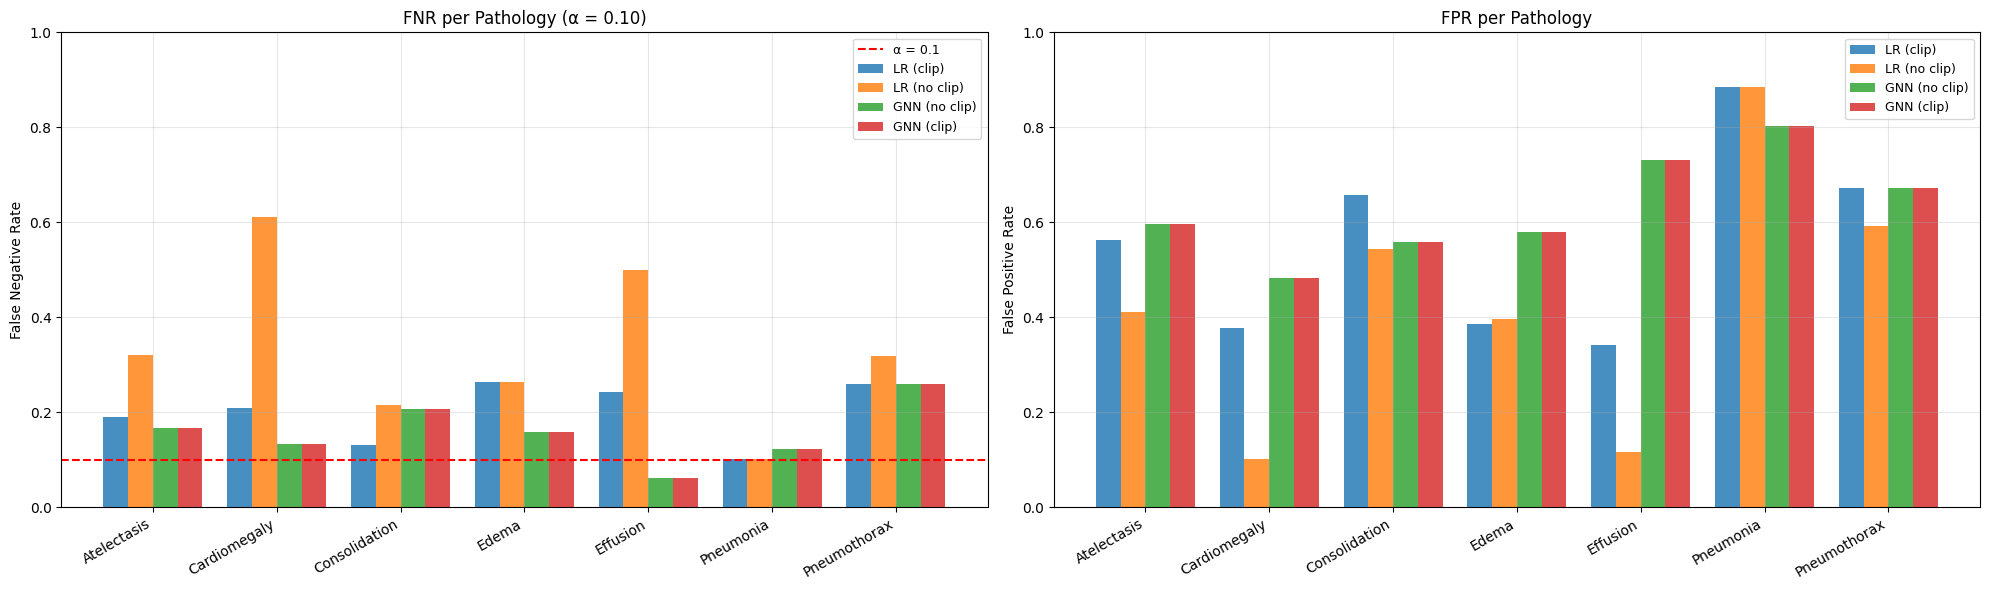

Saved figure.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
x     = np.arange(K)
width = 0.2
methods = [
    ('LR (clip)',    fnr_lr,       fpr_lr,       '#1f77b4'),
    ('LR (no clip)', fnr_lr_nc,    fpr_lr_nc,    '#ff7f0e'),
    ('GNN (no clip)',fnr_gnn,      fpr_gnn,      '#2ca02c'),
    ('GNN (clip)',   fnr_gnn_clip, fpr_gnn_clip, '#d62728'),
]
offsets = [-1.5, -0.5, 0.5, 1.5]

for ax, metric_idx, title, ylabel in [
    (axes[0], 0, 'FNR per Pathology (α = 0.10)', 'False Negative Rate'),
    (axes[1], 1, 'FPR per Pathology', 'False Positive Rate'),
]:
    for (label, fnr, fpr, color), off in zip(methods, offsets):
        vals = fnr if metric_idx == 0 else fpr
        ax.bar(x + off * width, vals, width, label=label, color=color, alpha=0.82)
    if metric_idx == 0:
        ax.axhline(ALPHA, ls='--', color='red', lw=1.5, label=f'α = {ALPHA}')
    ax.set_xticks(x);  ax.set_xticklabels(COMMON_PATHOLOGIES, rotation=30, ha='right')
    ax.set_title(title);  ax.set_ylabel(ylabel)
    ax.legend(fontsize=9);  ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(ROOT / 'report' / 'scrc_hard_fnr_barplot.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved figure.')


## 18. Figure 2: λ_k* Calibrated Thresholds

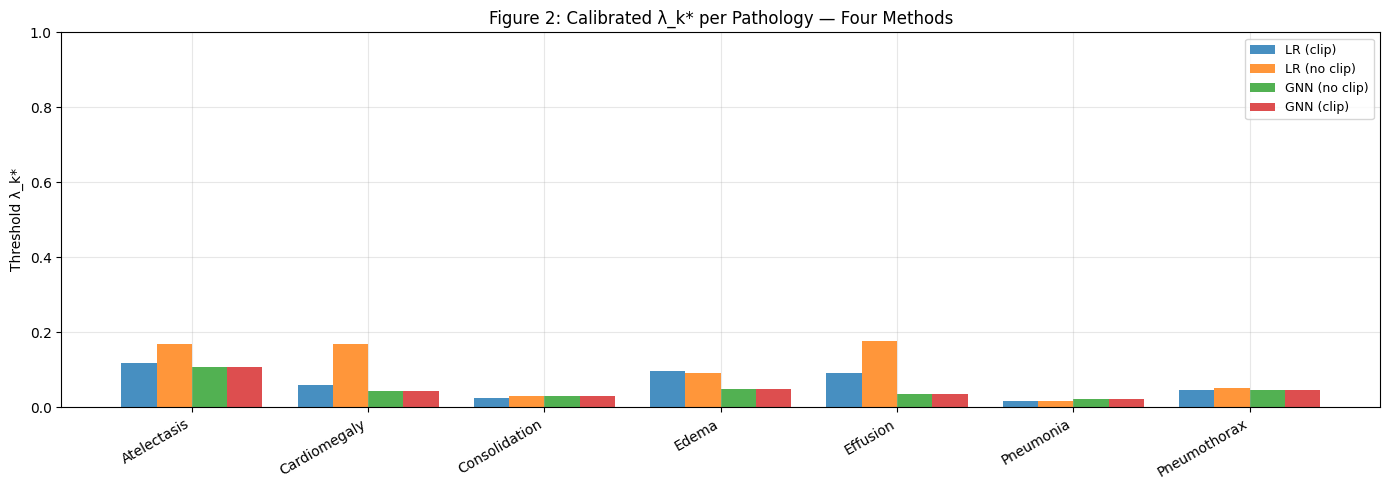

In [19]:
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(K)
w = 0.2
method_lambdas = [
    ('LR (clip)',    lambda_lr,       '#1f77b4'),
    ('LR (no clip)', lambda_lr_nc,    '#ff7f0e'),
    ('GNN (no clip)',lambda_gnn,      '#2ca02c'),
    ('GNN (clip)',   lambda_gnn_clip, '#d62728'),
]
offsets = [-1.5, -0.5, 0.5, 1.5]
for (label, lams, color), off in zip(method_lambdas, offsets):
    ax.bar(x + off * w, lams, w, label=label, color=color, alpha=0.82)
ax.set_xticks(x);  ax.set_xticklabels(COMMON_PATHOLOGIES, rotation=30, ha='right')
ax.set_title('Figure 2: Calibrated λ_k* per Pathology — Four Methods')
ax.set_ylabel('Threshold λ_k*')
ax.legend(fontsize=9);  ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(ROOT / 'report' / 'scrc_hard_fnr_lambda.png', dpi=130, bbox_inches='tight')
plt.show()


## 19. Per-Pathology ESS on Calibration Positives

In [20]:
kept   = ~defer_mask_cal
y_kept = Y_cal[kept]
ess_rows = []
for k, path in enumerate(COMMON_PATHOLOGIES):
    valid_k = ~np.isnan(y_kept[:, k])
    pos_k   = valid_k & (y_kept[:, k] == 1)
    def ess_pct(w):
        wp = w[pos_k]
        return 100.0 * (wp.sum()**2 / (wp**2).sum()) / pos_k.sum() if pos_k.sum() > 0 else float('nan')
    ess_rows.append({
        'Pathology': path,
        'N_pos':     int(pos_k.sum()),
        'ESS% LR(c)':    round(ess_pct(w_cal_lr[kept]),       1),
        'ESS% LR(nc)':   round(ess_pct(w_cal_lr_nc[kept]),    1),
        'ESS% GNN(nc)':  round(ess_pct(w_cal_gnn[kept]),      1),
        'ESS% GNN(c)':   round(ess_pct(w_cal_gnn_clip[kept]), 1),
    })
df_ess = pd.DataFrame(ess_rows)
print(df_ess.to_string(index=False))


    Pathology  N_pos  ESS% LR(c)  ESS% LR(nc)  ESS% GNN(nc)  ESS% GNN(c)
  Atelectasis   2045         3.8          1.1          30.6         30.6
 Cardiomegaly   1523         4.0          1.2          27.3         27.3
Consolidation    847         3.4          0.5          21.4         21.4
        Edema   2434         3.7          0.8          26.8         26.8
     Effusion   3243         2.7          0.6          20.5         20.5
    Pneumonia    432         6.3          6.3          28.2         28.2
 Pneumothorax    642         3.9          0.8          27.0         27.0


## 20. Summary

**Architecture**: Two-stage SCRC with strict per-pathology FNR calibration.
- Stage 1 defers the top-β=0.15 most uncertain samples (by multi-label entropy).
- Stage 2 calibrates a per-pathology threshold λ_k* to bound FNR ≤ α=0.10
  using DRE-weighted quantiles over positive calibration samples.


In [21]:
print('=' * 85)
print('SCRC Hard FNR Experiment Summary — Four Methods')
print('=' * 85)
print(f'\nBeta (stage-1 deferral rate): {BETA},  Alpha (FNR target): {ALPHA}')
print(f'Deferred (cal):  {defer_mask_cal.mean()*100:.1f}%')
print(f'Deferred (test): {defer_mask_nih.mean()*100:.1f}%')
print()
hdr = f"{'Method':20s} | {'ESS%':5s} | {'W_max':7s} | {'Mean λ*':7s} | {'CalFNR':6s} | {'TestFNR':7s} | {'TestFPR':7s} | {'ΔCal→Test':10s}"
print(hdr)
print('-' * len(hdr))
configs = [
    ('LR (clip=20)',   diag_lr.ess_fraction * 100,       float(w_cal_lr.max()),       lambda_lr,       cal_fnr_lr,       fnr_lr,       fpr_lr),
    ('LR (no clip)',   diag_lr_nc.ess_fraction * 100,    float(w_cal_lr_nc.max()),    lambda_lr_nc,    cal_fnr_lr_nc,    fnr_lr_nc,    fpr_lr_nc),
    ('GNN-DRE (nc)',   diag_gnn.ess_fraction * 100,      float(w_cal_gnn.max()),      lambda_gnn,      cal_fnr_gnn,      fnr_gnn,      fpr_gnn),
    ('GNN-DRE (clip)', diag_gnn_clip.ess_fraction * 100, float(w_cal_gnn_clip.max()), lambda_gnn_clip, cal_fnr_gnn_clip, fnr_gnn_clip, fpr_gnn_clip),
]
for name, ess, wmax, lams, cal_fnrs, test_fnrs, test_fprs in configs:
    delta = np.nanmean(test_fnrs) - np.nanmean(cal_fnrs)
    print(f"{name:20s} | {ess:5.1f} | {wmax:7.1f} | {lams.mean():7.3f} | {np.nanmean(cal_fnrs):6.3f} | {np.nanmean(test_fnrs):7.3f} | {np.nanmean(test_fprs):7.3f} | {delta:+.3f}")
print()
print('Cal FNR sanity (all ≤ alpha):')
for name, fnrs in [('LR(c)', cal_fnr_lr), ('LR(nc)', cal_fnr_lr_nc), ('GNN(nc)', cal_fnr_gnn), ('GNN(c)', cal_fnr_gnn_clip)]:
    ok = (fnrs <= ALPHA + 1e-9).all()
    print(f'  {name}: {"PASS" if ok else "FAIL"}')


SCRC Hard FNR Experiment Summary — Four Methods

Beta (stage-1 deferral rate): 0.15,  Alpha (FNR target): 0.1
Deferred (cal):  15.0%
Deferred (test): 15.0%

Method               | ESS%  | W_max   | Mean λ* | CalFNR | TestFNR | TestFPR | ΔCal→Test 
------------------------------------------------------------------------------------------
LR (clip=20)         |   6.0 |    20.0 |   0.065 |  0.093 |   0.200 |   0.555 | +0.107
LR (no clip)         |   0.3 |  2510.5 |   0.101 |  0.081 |   0.333 |   0.435 | +0.252
GNN-DRE (nc)         |  30.9 |    50.5 |   0.049 |  0.098 |   0.158 |   0.632 | +0.060
GNN-DRE (clip)       |  32.6 |    20.0 |   0.049 |  0.098 |   0.158 |   0.632 | +0.060

Cal FNR sanity (all ≤ alpha):
  LR(c): PASS
  LR(nc): PASS
  GNN(nc): PASS
  GNN(c): PASS
